# Unemployment Analysis with Python

## CodeAlpha Data Science Internship

### Objective
Analyze unemployment rate data in India to understand unemployment trends, investigate the impact of COVID-19, identify important patterns, and derive meaningful insights.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv('/content/Unemployment in India.csv')
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [9]:
raw_df = pd.read_csv('/content/Unemployment in India.csv')
raw_df.shape

(754, 7)

In [ ]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [14]:
df.columns = df.columns.str.strip()
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [ ]:
df = df.dropna(how='all')

In [ ]:
df.isnull().sum()

,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Area,0


In [ ]:
df.dtypes

,0
Region,object
Date,object
Frequency,object
Estimated Unemployment Rate (%),float64
Estimated Employed,float64
Estimated Labour Participation Rate (%),float64
Area,object


In [ ]:
df['Date'] = pd.to_datetime(df['Date'],dayfirst=True)

In [ ]:
df.dtypes

,0
Region,object
Date,datetime64[ns]
Frequency,object
Estimated Unemployment Rate (%),float64
Estimated Employed,float64
Estimated Labour Participation Rate (%),float64
Area,object


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


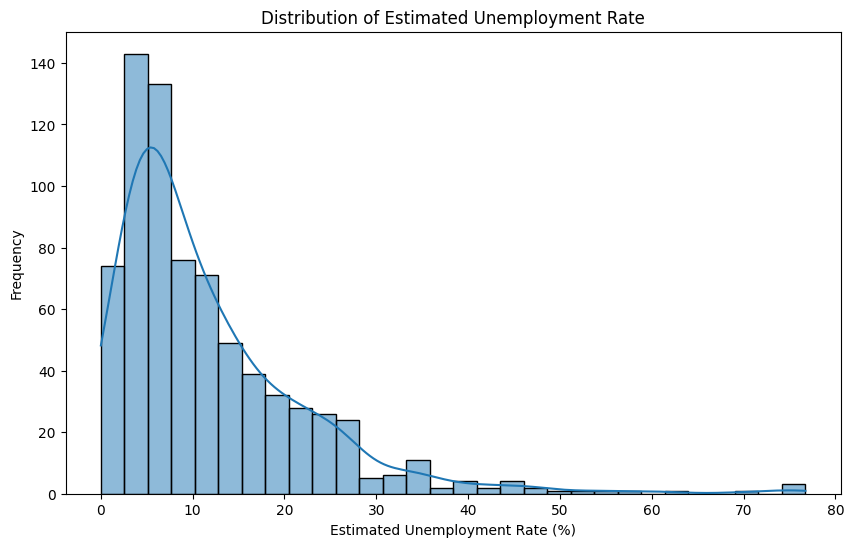

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data=df,x='Estimated Unemployment Rate (%)',bins=30,kde=True)
plt.title('Distribution of Estimated Unemployment Rate')
plt.xlabel('Estimated Unemployment Rate (%)')
plt.ylabel('Frequency')
plt.show()

### Observation

The unemployment rate distribution is positively skewed, with most observations concentrated in the lower range. Most unemployment rates are below 15%, while a small number of observations show unusually high unemployment rates. The long right tail indicates the presence of high-value observations in the dataset.

In [ ]:
monthly_unemployment = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()
monthly_unemployment

,Estimated Unemployment Rate (%)
Date,
2019-05-31,8.874259
2019-06-30,9.303333
2019-07-31,9.033889
2019-08-31,9.637925
2019-09-30,9.051731
2019-10-31,9.900909
2019-11-30,9.868364
2019-12-31,9.497358
2020-01-31,9.950755


### Observation

The monthly average unemployment rate remained relatively stable between May 2019 and February 2020, mostly around 9–10%. A noticeable increase occurred in March 2020, followed by a sharp rise in April and May 2020. The monthly average reached approximately 24.88% in May 2020. In June 2020, the unemployment rate declined considerably to around 11.90%. This sharp change during April and May 2020 highlights a significant disruption in employment conditions during the COVID-19 period.

In [ ]:
before_covid = df[df['Date'] < '2020-03-01']
covid_period = df[df['Date'] >= '2020-03-01']

before_covid_rate = before_covid['Estimated Unemployment Rate (%)'].mean()
covid_period_rate = covid_period['Estimated Unemployment Rate (%)'].mean()

print("Average Unemployment rate before March 2020:",round(before_covid_rate,2), "%")
print("Average Unemployment rate from March 2020:",round(covid_period_rate,2), "%")

Average Unemployment rate before March 2020: 9.51 %
Average Unemployment rate from March 2020: 17.77 %


###Observation
A sharp increase was observed
during the COVID-19 period.

In [ ]:
area_analysis = df.groupby('Area')['Estimated Unemployment Rate (%)'].mean()
area_analysis

,Estimated Unemployment Rate (%)
Area,
Rural,10.324791
Urban,13.166614


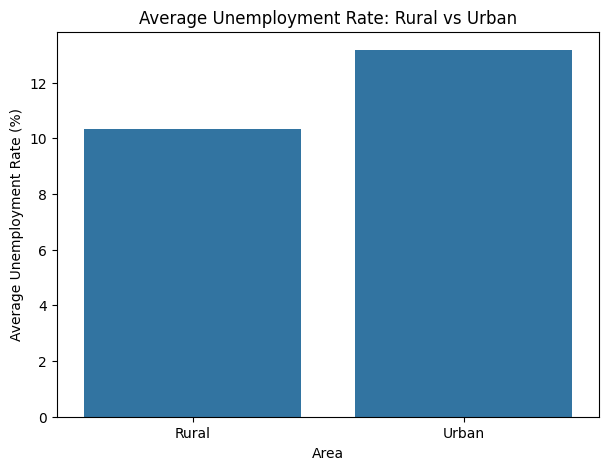

In [ ]:
plt.figure(figsize=(7,5))

sns.barplot(x=area_analysis.index,y=area_analysis.values)
plt.title('Average Unemployment Rate: Rural vs Urban')
plt.xlabel('Area')
plt.ylabel('Average Unemployment Rate (%)')
plt.show()

### Observation

The average unemployment rate in urban areas was approximately 13.17%, compared with 10.32% in rural areas. Thus, the dataset shows a higher average unemployment rate in urban areas than in rural areas.

In [21]:
region_analysis = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()
region_analysis.sort_values(ascending=False)

,Estimated Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


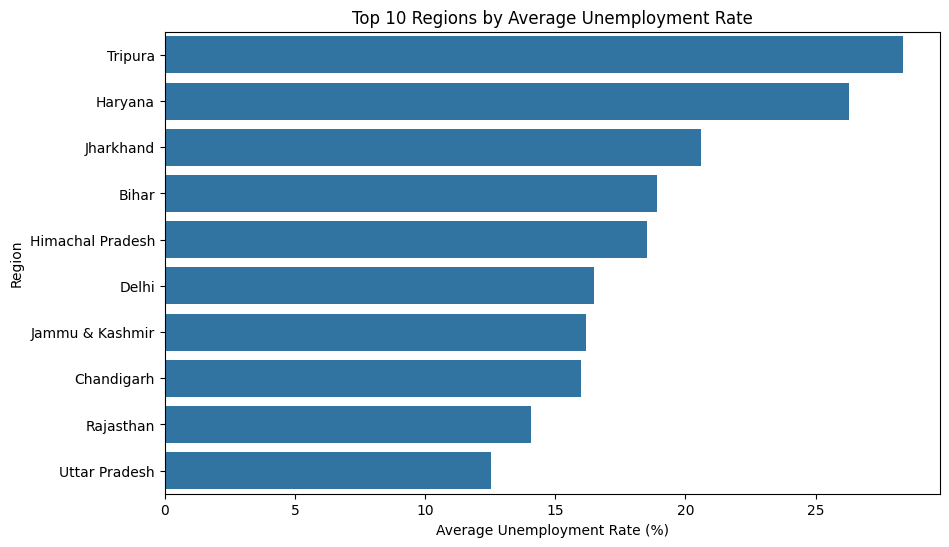

In [ ]:
top_10_regions = region_analysis.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=top_10_regions.values,y=top_10_regions.index)
plt.title('Top 10 Regions by Average Unemployment Rate')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('Region')
plt.show()

### Observation

The regional analysis shows considerable variation in average unemployment rates. Tripura recorded the highest average unemployment rate at approximately 28.35%, followed by Haryana at 26.28%. On the other hand, regions such as Meghalaya and Odisha had comparatively lower average unemployment rates.


In [16]:
covid_period = df[df['Date'] >= '2020-03-01']
covid_period

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
10,Andhra Pradesh,2020-03-31,Monthly,4.06,11359660.0,40.66,Rural
11,Andhra Pradesh,2020-04-30,Monthly,16.29,8792827.0,36.03,Rural
12,Andhra Pradesh,2020-05-31,Monthly,14.46,9526902.0,38.16,Rural
13,Andhra Pradesh,2020-06-30,Monthly,0.85,15572975.0,53.76,Rural
23,Assam,2020-03-31,Monthly,3.77,9878742.0,47.05,Rural


In [17]:
covid_avg = covid_period['Estimated Unemployment Rate (%)'].mean()
print("Average Unemployment Rate during COVID-19 period:",round(covid_avg,2),"%")

Average Unemployment Rate during COVID-19 period: 17.77 %


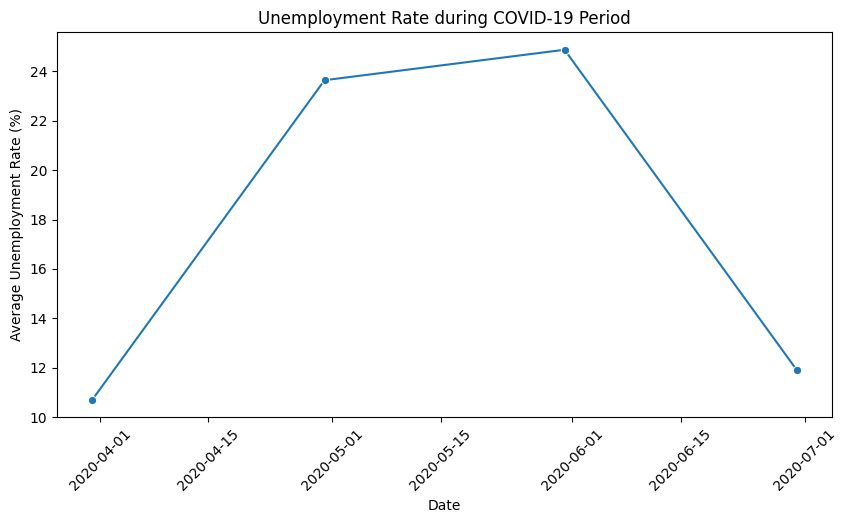

In [18]:
monthly_covid = (covid_period.groupby('Date')['Estimated Unemployment Rate (%)'].mean())
plt.figure(figsize=(10,5))
sns.lineplot(x = monthly_covid.index, y = monthly_covid.values, marker = 'o')
plt.title('Unemployment Rate during COVID-19 Period')
plt.xlabel('Date')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.show()

###Observation — COVID-19 Impact

The unemployment rate increased sharply during the COVID-19 period. The average unemployment rate rose from around 9.51% before March 2020 to 17.77% from March 2020 onwards. The unemployment rate reached its highest monthly average in May 2020 at approximately 24.88%. It then declined to around 11.90% in June 2020, indicating a partial recovery.

In [19]:
df['Month'] = df['Date'].dt.month_name()

monthly_pattern = (df.groupby('Month')['Estimated Unemployment Rate (%)'].mean())
monthly_pattern

,Estimated Unemployment Rate (%)
Month,
April,23.641569
August,9.637925
December,9.497358
February,9.964717
January,9.950755
July,9.033889
June,10.553462
March,10.700577
May,16.646190


In [22]:
bottom_10_regions = region_analysis.sort_values(ascending = True).head(10)
bottom_10_regions

,Estimated Unemployment Rate (%)
Region,
Meghalaya,4.798889
Odisha,5.657857
Assam,6.428077
Uttarakhand,6.582963
Gujarat,6.663929
Karnataka,6.676071
Sikkim,7.249412
Madhya Pradesh,7.406429
Andhra Pradesh,7.477143


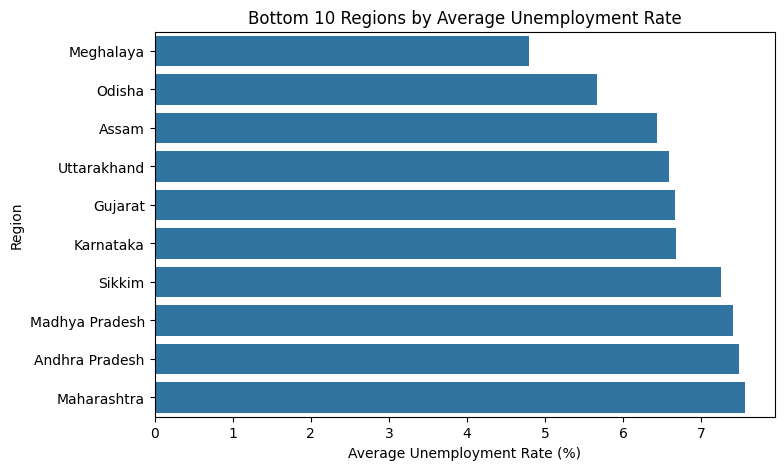

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(x = bottom_10_regions.values, y = bottom_10_regions.index)
plt.title('Bottom 10 Regions by Average Unemployment Rate')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('Region')
plt.show()

###Observation

The bottom 10 regions have comparatively lower average unemployment rates. This shows that unemployment levels vary considerably across different regions of India. Some regions experience relatively lower unemployment compared to regions with higher unemployment rates.

In [24]:
pre_covid = df[df['Date'] < '2020-03-01']

covid_period = df[(df['Date'] >= '2020-03-01') & (df['Date'] <= '2020-06-30')]

pre_covid_region = pre_covid.groupby('Region')['Estimated Unemployment Rate (%)'].mean()
covid_region = covid_period.groupby('Region')['Estimated Unemployment Rate (%)'].mean()
covid_change = (covid_region - pre_covid_region).sort_values(ascending=False)
covid_change.head(10)

,Estimated Unemployment Rate (%)
Region,
Puducherry,37.36200
Tamil Nadu,22.56725
Jharkhand,22.06925
Bihar,17.79825
Karnataka,12.04550
Haryana,11.71700
Kerala,10.96000
Telangana,10.78650
Madhya Pradesh,9.32900


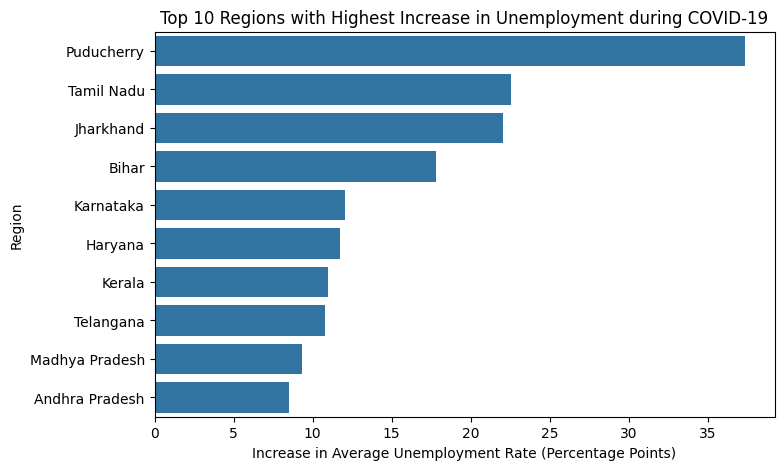

In [25]:
top_covid_impact = covid_change.head(10)

plt.figure(figsize=(8,5))

sns.barplot(x=top_covid_impact.values,y=top_covid_impact.index)
plt.title('Top 10 Regions with Highest Increase in Unemployment during COVID-19')
plt.xlabel('Increase in Average Unemployment Rate (Percentage Points)')
plt.ylabel('Region')
plt.show()

In [26]:
#arrange months in calender order
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'
]
monthly_pattern = monthly_pattern.reindex(month_order)
monthly_pattern


,Estimated Unemployment Rate (%)
Month,
January,9.950755
February,9.964717
March,10.700577
April,23.641569
May,16.646190
June,10.553462
July,9.033889
August,9.637925
September,9.051731


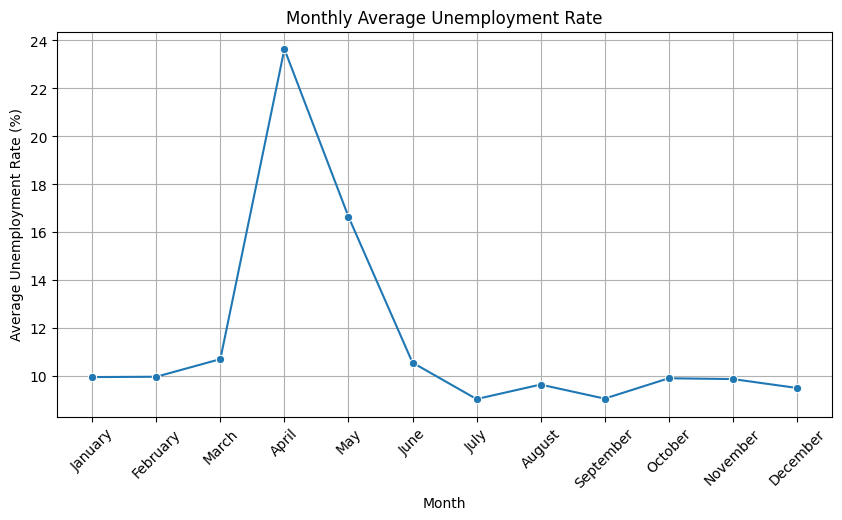

In [27]:
plt.figure(figsize=(10,5))

sns.lineplot(x=monthly_pattern.index, y=monthly_pattern.values, marker='o')
plt.title('Monthly Average Unemployment Rate')
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

###Observation

The monthly analysis shows that unemployment rates were relatively stable during most of 2019 and early 2020. A sharp increase can be observed during April and May 2020, indicating the strong impact of the COVID-19 period on employment. The unemployment rate gradually decreased in June 2020.

In [28]:
correlation = df[['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']].corr()
correlation

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


###Observation:
The correlation analysis shows a weak negative relationship (-0.223) between unemployment rate and estimated employment. This indicates that higher unemployment is generally associated with lower estimated employment, but the relationship is not very strong. The correlation between unemployment rate and labour participation rate is almost zero (0.003), indicating little linear relationship between the two variables.

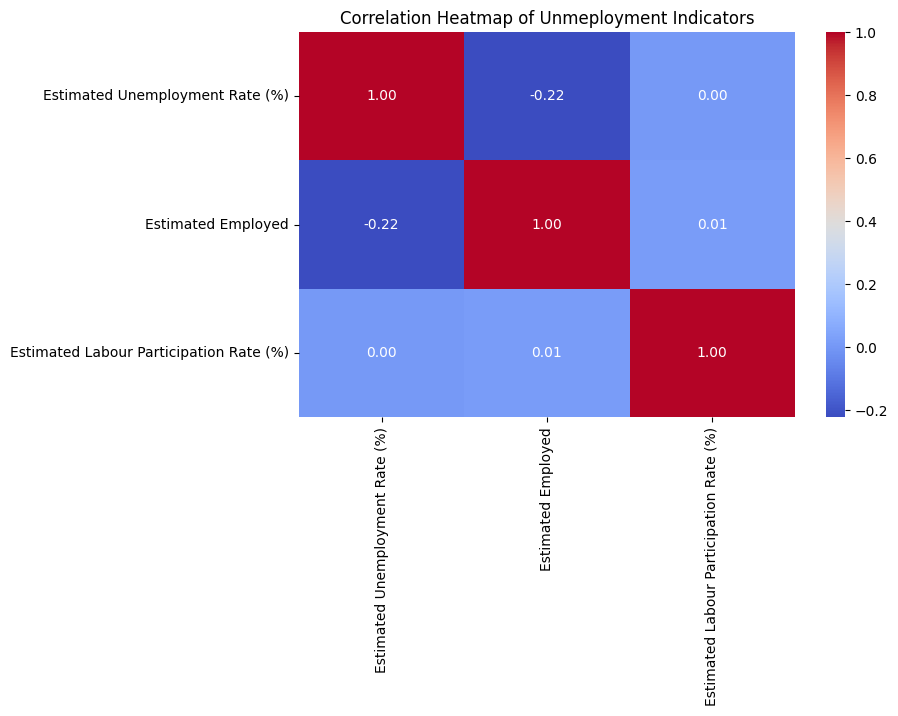

In [31]:
plt.figure(figsize=(8,5))

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Unmeployment Indicators')
plt.show()

#Final Insights
1. COVID-19 Impact: Unemployment increased sharply during April and May 2020. The average unemployment rate increased from approximately 9.51% before March 2020 to 17.77% from March 2020 onward, indicating a significant increase in unemployment during the COVID-19 period.

2. Monthly Trend: Unemployment remained relatively stable during 2019 and early 2020, followed by a major increase during the COVID-19 period.

3. Rural vs Urban: The average unemployment rate was higher in urban areas (13.17%) compared to rural areas (10.32%).

4. Regional Variation: There was considerable variation among regions. Tripura had the highest average unemployment rate, while Meghalaya had the lowest among the regions analyzed.

5. COVID-19 Regional Impact: Puducherry showed the highest increase in average unemployment rate during the COVID-19 period, followed by Tamil Nadu and Jharkhand.

6. Correlation: The unemployment rate showed a weak negative correlation with estimated employment (-0.22), while its correlation with labour participation was almost zero.

#Conclusion
This analysis provides an overview of unemployment trends in India using Python. The analysis shows that COVID-19 had a significant impact on unemployment, particularly during April and May 2020. Urban areas recorded a higher average unemployment rate than rural areas, while unemployment varied considerably across regions. The analysis also identified regional differences in the impact of COVID-19 and examined relationships between unemployment, employment, and labour participation.